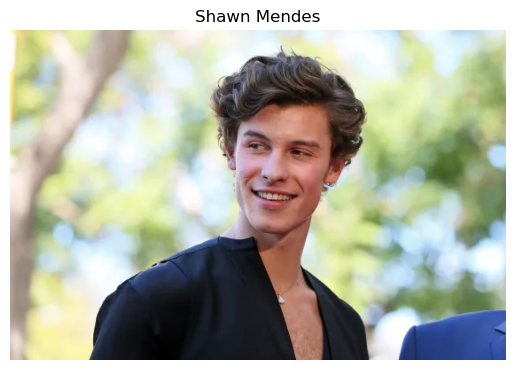

In [2]:
import cv2
import matplotlib.pyplot as plt

image_path = "C:/Users/student/Documents/Computer Vision 2023510051/Shawn.webp"
image = cv2.imread(image_path)

rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(rgb_image)
plt.axis('off')  # Hide axes
plt.title('Shawn Mendes')
plt.show()


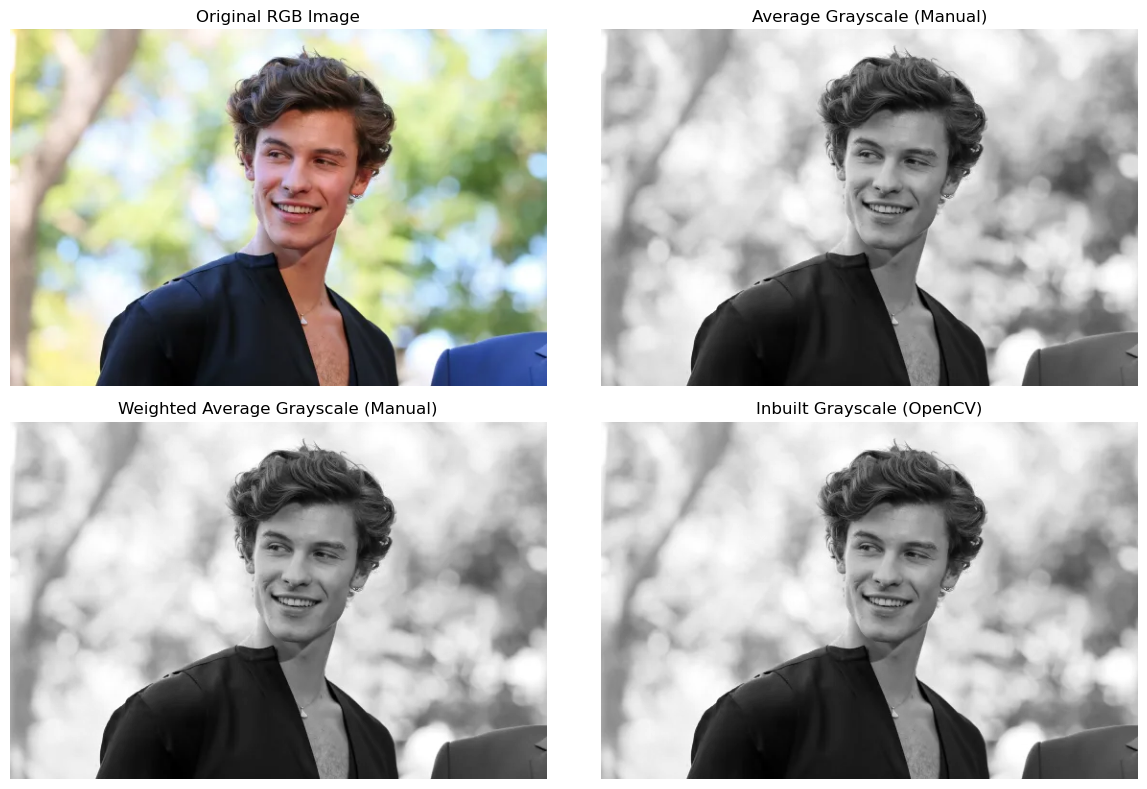

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load the RGB image
image_path = "C:/Users/student/Documents/Computer Vision 2023510051/Shawn.webp"  # Image path
rgb_image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)

# Method 1: Average Grayscale (Manual)
average_gray = np.mean(rgb_image, axis=2).astype(np.uint8)

# Method 2: Weighted Average Grayscale (Manual) using standard weights for RGB
weights = [0.2989, 0.5870, 0.1140]  # Standard weights for human perception
weighted_gray = np.dot(rgb_image[..., :3], weights).astype(np.uint8)

# Method 3: Using inbuilt function (OpenCV)
inbuilt_gray = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2GRAY)

# Plot the results
plt.figure(figsize=(12, 8))

# Original RGB Image
plt.subplot(2, 2, 1)
plt.imshow(rgb_image)
plt.title("Original RGB Image")
plt.axis("off")

# Average Grayscale (Manual)
plt.subplot(2, 2, 2)
plt.imshow(average_gray, cmap="gray")
plt.title("Average Grayscale (Manual)")
plt.axis("off")

# Weighted Average Grayscale (Manual)
plt.subplot(2, 2, 3)
plt.imshow(weighted_gray, cmap="gray")
plt.title("Weighted Average Grayscale (Manual)")
plt.axis("off")

# Inbuilt Grayscale (OpenCV)
plt.subplot(2, 2, 4)
plt.imshow(inbuilt_gray, cmap="gray")
plt.title("Inbuilt Grayscale (OpenCV)")
plt.axis("off")

plt.tight_layout()
plt.show()


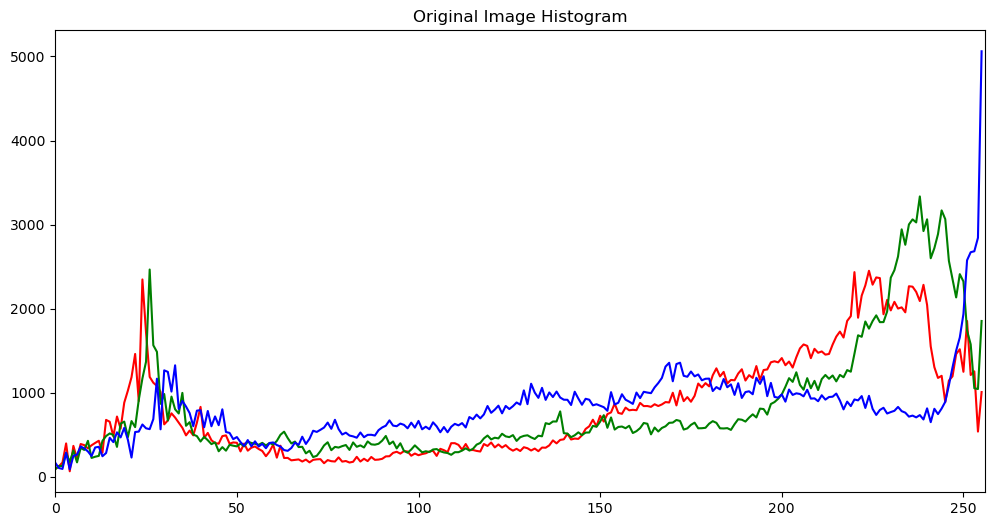

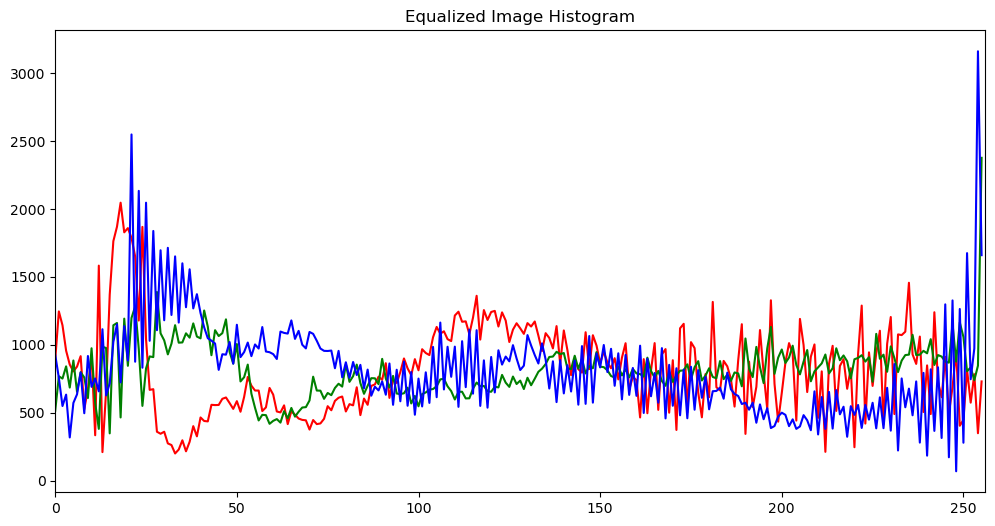

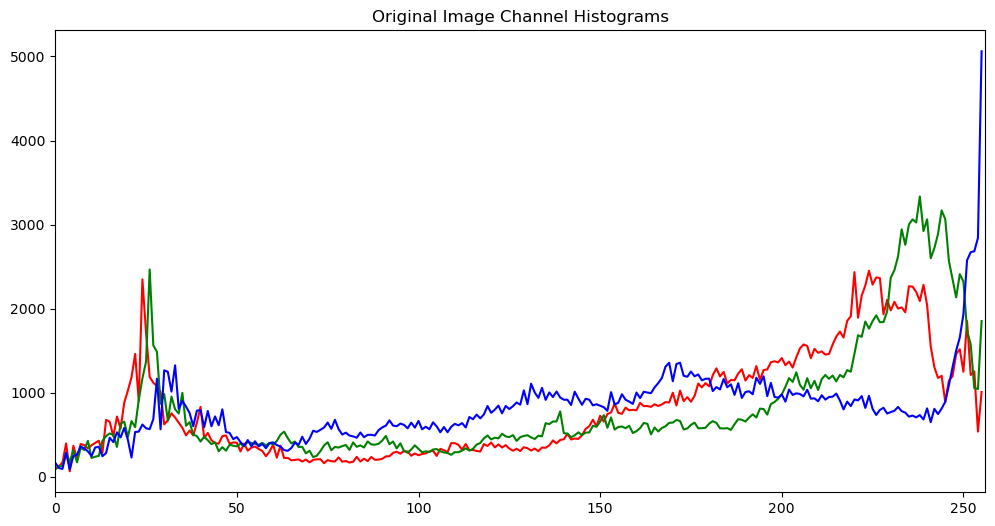

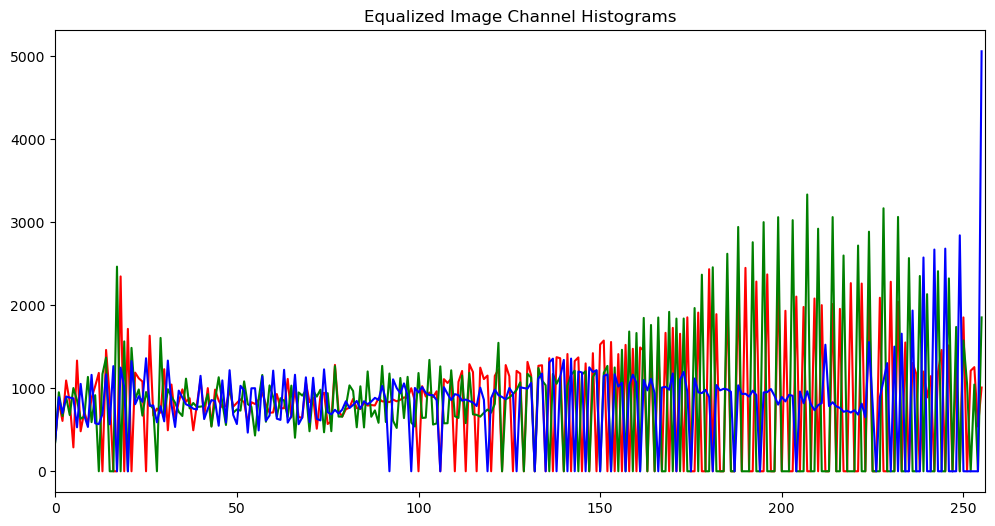

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load the RGB image
image_path = "C:/Users/student/Documents/Computer Vision 2023510051/Shawn.webp"  # Image path
rgb_image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)

# Function to perform histogram equalization for a given image
def equalize_histogram(image):
    # Convert to YUV color space (Y is luminance, U and V are chrominance)
    img_yuv = cv2.cvtColor(image, cv2.COLOR_RGB2YUV)
    img_yuv[:, :, 0] = cv2.equalizeHist(img_yuv[:, :, 0])  # Equalize the Y channel (luminance)
    equalized_image = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)  # Convert back to RGB
    return equalized_image

# Perform histogram equalization for the entire image
equalized_rgb_image = equalize_histogram(rgb_image)

# Function to plot histograms for the RGB image
def plot_histogram(image, title):
    # Calculate histograms for R, G, B channels
    color = ('r', 'g', 'b')
    plt.figure(figsize=(12, 6))
    plt.title(title)
    
    for i, col in enumerate(color):
        hist = cv2.calcHist([image], [i], None, [256], [0, 256])
        plt.plot(hist, color=col)
        plt.xlim([0, 256])
    
    plt.show()

# Plot the histogram of the original and equalized images
plot_histogram(rgb_image, 'Original Image Histogram')

# Plot the histogram of the equalized image (entire image equalization)
plot_histogram(equalized_rgb_image, 'Equalized Image Histogram')

# Function to equalize individual color channels and plot the results
def equalize_and_plot_channels(image):
    # Equalize each channel separately
    r, g, b = cv2.split(image)
    r_equalized = cv2.equalizeHist(r)
    g_equalized = cv2.equalizeHist(g)
    b_equalized = cv2.equalizeHist(b)

    # Merge the equalized channels back
    equalized_image_individual = cv2.merge([r_equalized, g_equalized, b_equalized])

    # Plot histograms for each individual channel
    plt.figure(figsize=(12, 6))
    color = ('r', 'g', 'b')
    for i, col in enumerate(color):
        hist = cv2.calcHist([image], [i], None, [256], [0, 256])
        plt.plot(hist, color=col)
        plt.xlim([0, 256])
    
    plt.title('Original Image Channel Histograms')
    plt.show()

    # Plot histograms for the equalized channels
    plt.figure(figsize=(12, 6))
    for i, col in enumerate(color):
        hist = cv2.calcHist([equalized_image_individual], [i], None, [256], [0, 256])
        plt.plot(hist, color=col)
        plt.xlim([0, 256])
    
    plt.title('Equalized Image Channel Histograms')
    plt.show()

# Call the function to equalize and plot individual channels
equalize_and_plot_channels(rgb_image)


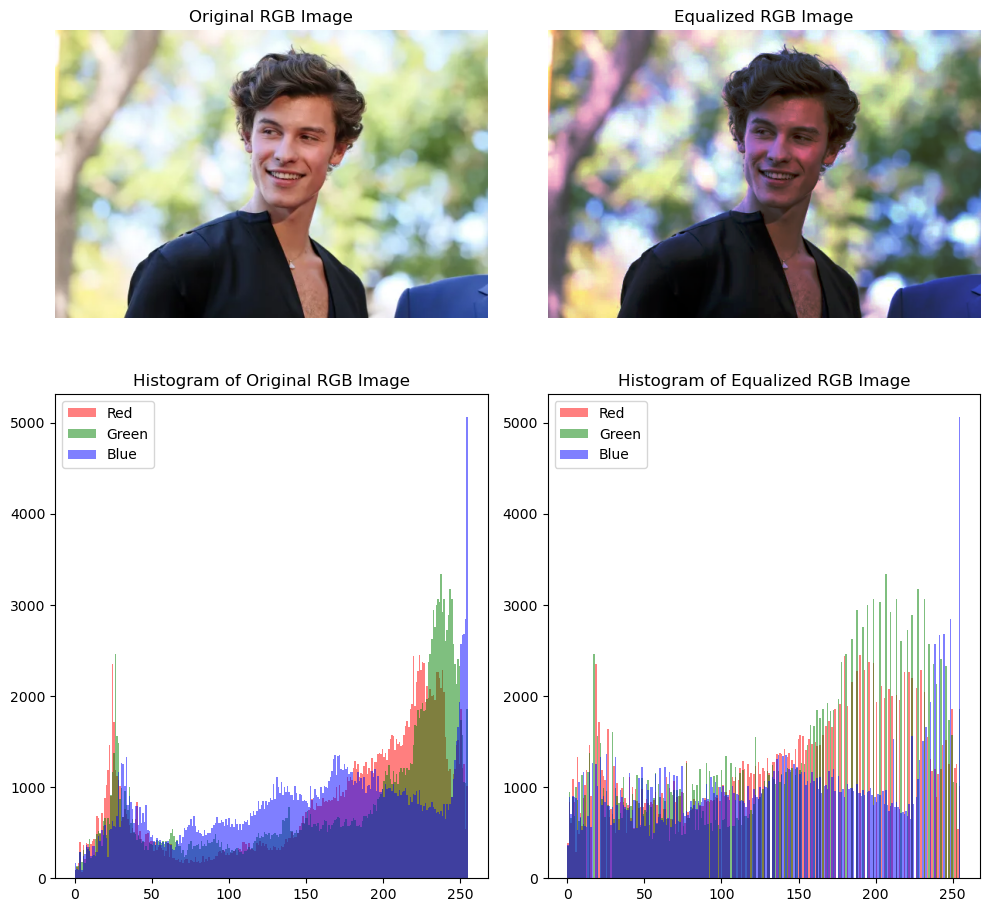

In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load the image
image_path = "C:/Users/student/Documents/Computer Vision 2023510051/Shawn.webp"
image = cv2.imread(image_path)

# Convert the image from BGR to RGB (OpenCV loads images in BGR by default)
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Split the image into its RGB channels
r, g, b = cv2.split(rgb_image)

# Perform histogram equalization on each channel
r_equalized = cv2.equalizeHist(r)
g_equalized = cv2.equalizeHist(g)
b_equalized = cv2.equalizeHist(b)

# Merge the equalized channels back together
equalized_rgb_image = cv2.merge([r_equalized, g_equalized, b_equalized])

# Plot the original and equalized images along with their histograms
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Original Image
axes[0, 0].imshow(rgb_image)
axes[0, 0].set_title('Original RGB Image')
axes[0, 0].axis('off')

# Equalized Image
axes[0, 1].imshow(equalized_rgb_image)
axes[0, 1].set_title('Equalized RGB Image')
axes[0, 1].axis('off')

# Histogram of the original image (for each channel)
axes[1, 0].hist(r.ravel(), bins=256, color='red', alpha=0.5, label='Red')
axes[1, 0].hist(g.ravel(), bins=256, color='green', alpha=0.5, label='Green')
axes[1, 0].hist(b.ravel(), bins=256, color='blue', alpha=0.5, label='Blue')
axes[1, 0].set_title('Histogram of Original RGB Image')
axes[1, 0].legend()

# Histogram of the equalized image (for each channel)
axes[1, 1].hist(r_equalized.ravel(), bins=256, color='red', alpha=0.5, label='Red')
axes[1, 1].hist(g_equalized.ravel(), bins=256, color='green', alpha=0.5, label='Green')
axes[1, 1].hist(b_equalized.ravel(), bins=256, color='blue', alpha=0.5, label='Blue')
axes[1, 1].set_title('Histogram of Equalized RGB Image')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


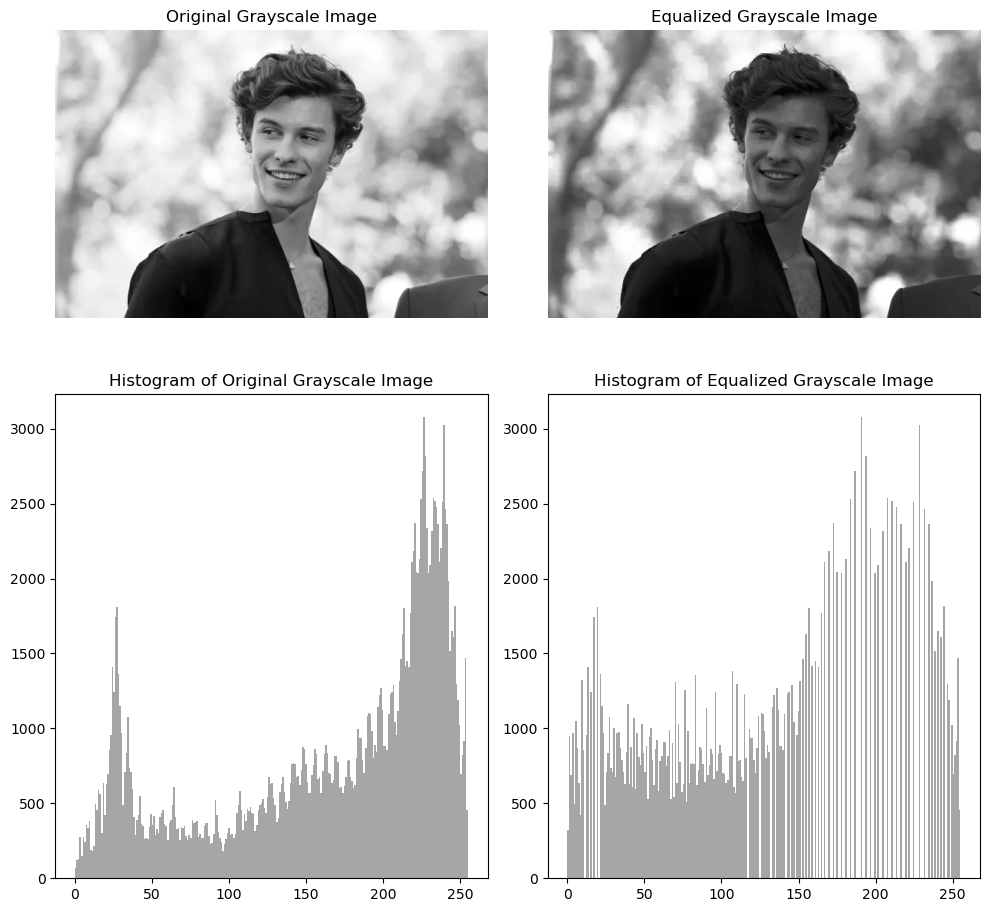

In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load the grayscale image
image_path = "C:/Users/student/Documents/Computer Vision 2023510051/Shawn.webp"
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Load as grayscale

# Perform histogram equalization
equalized_image = cv2.equalizeHist(image)

# Plot the original and equalized images along with their histograms
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Original Image (Grayscale)
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original Grayscale Image')
axes[0, 0].axis('off')

# Equalized Image (Grayscale)
axes[0, 1].imshow(equalized_image, cmap='gray')
axes[0, 1].set_title('Equalized Grayscale Image')
axes[0, 1].axis('off')

# Histogram of the original grayscale image
axes[1, 0].hist(image.ravel(), bins=256, color='gray', alpha=0.7)
axes[1, 0].set_title('Histogram of Original Grayscale Image')

# Histogram of the equalized grayscale image
axes[1, 1].hist(equalized_image.ravel(), bins=256, color='gray', alpha=0.7)
axes[1, 1].set_title('Histogram of Equalized Grayscale Image')

plt.tight_layout()
plt.show()


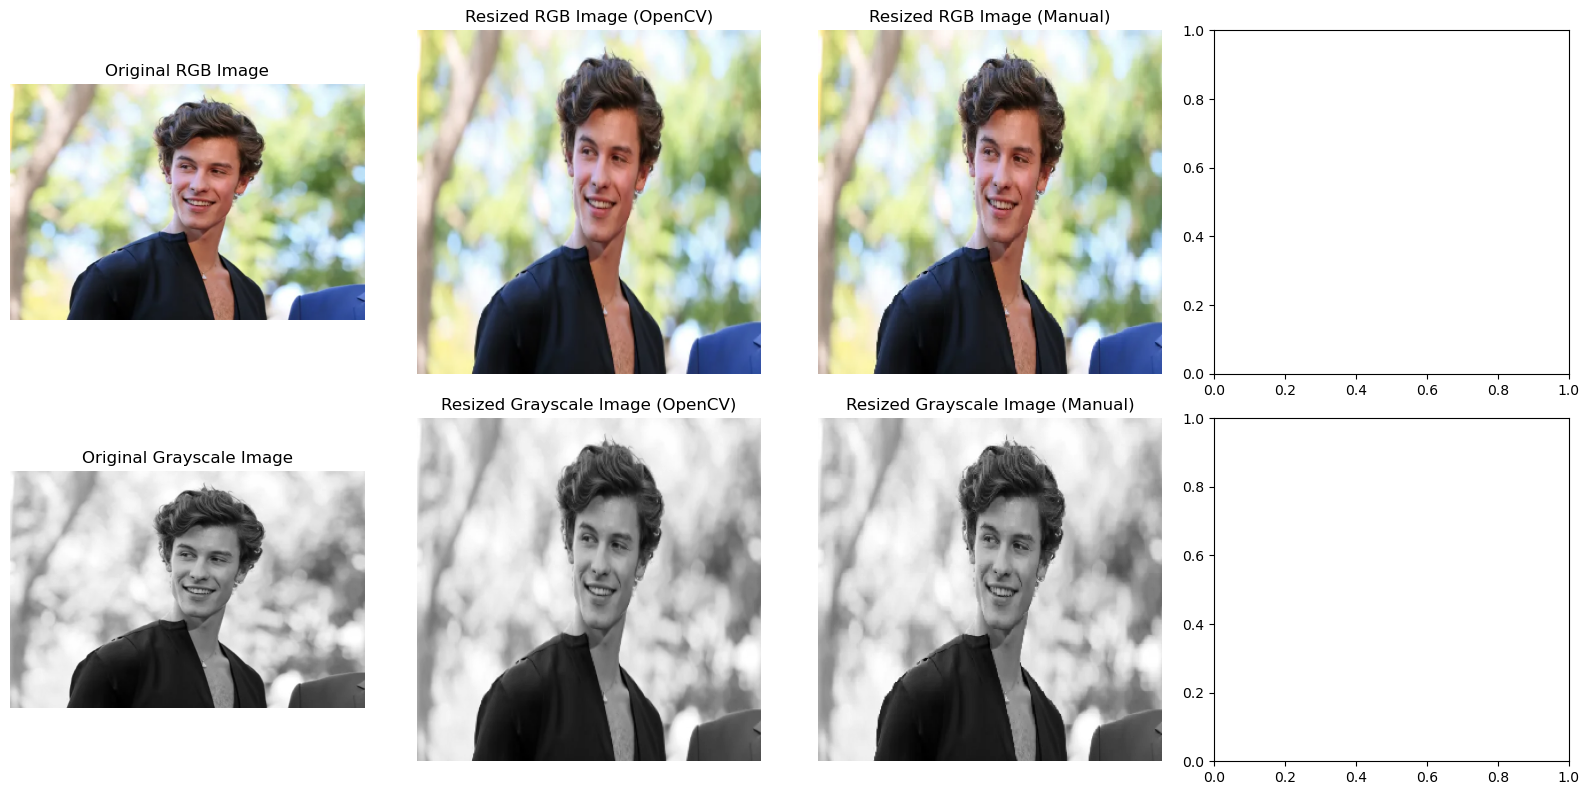

In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load the image in RGB and Grayscale
image_path = "C:/Users/student/Documents/Computer Vision 2023510051/Shawn.webp"

# Read the RGB image (OpenCV loads images in BGR by default, so we convert it to RGB)
rgb_image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)

# Read the Grayscale image
gray_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Function to resize an image manually using bilinear interpolation
def resize_manual(image, new_width, new_height):
    height, width = image.shape[:2]
    
    # Initialize the resized image with the new size
    if len(image.shape) == 2:  # Grayscale image
        resized_image = np.zeros((new_height, new_width), dtype=image.dtype)
    else:  # RGB image
        resized_image = np.zeros((new_height, new_width, image.shape[2]), dtype=image.dtype)

    # Calculate scaling factors
    row_scale = height / new_height
    col_scale = width / new_width

    for i in range(new_height):
        for j in range(new_width):
            # Get the corresponding position in the original image
            orig_x = int(j * col_scale)
            orig_y = int(i * row_scale)

            if len(image.shape) == 2:  # Grayscale image
                resized_image[i, j] = image[orig_y, orig_x]
            else:  # RGB image
                resized_image[i, j, :] = image[orig_y, orig_x, :]

    return resized_image

# Resizing the RGB and Grayscale images using OpenCV
new_width = 300
new_height = 300

resized_rgb_opencv = cv2.resize(rgb_image, (new_width, new_height))
resized_gray_opencv = cv2.resize(gray_image, (new_width, new_height))

# Resizing the RGB and Grayscale images manually
resized_rgb_manual = resize_manual(rgb_image, new_width, new_height)
resized_gray_manual = resize_manual(gray_image, new_width, new_height)

# Plot the original and resized images (both RGB and grayscale) with their respective methods
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Original RGB Image
axes[0, 0].imshow(rgb_image)
axes[0, 0].set_title('Original RGB Image')
axes[0, 0].axis('off')

# Resized RGB Image using OpenCV
axes[0, 1].imshow(resized_rgb_opencv)
axes[0, 1].set_title('Resized RGB Image (OpenCV)')
axes[0, 1].axis('off')

# Resized RGB Image using Manual Function
axes[0, 2].imshow(resized_rgb_manual)
axes[0, 2].set_title('Resized RGB Image (Manual)')
axes[0, 2].axis('off')

# Original Grayscale Image
axes[1, 0].imshow(gray_image, cmap='gray')
axes[1, 0].set_title('Original Grayscale Image')
axes[1, 0].axis('off')

# Resized Grayscale Image using OpenCV
axes[1, 1].imshow(resized_gray_opencv, cmap='gray')
axes[1, 1].set_title('Resized Grayscale Image (OpenCV)')
axes[1, 1].axis('off')

# Resized Grayscale Image using Manual Function
axes[1, 2].imshow(resized_gray_manual, cmap='gray')
axes[1, 2].set_title('Resized Grayscale Image (Manual)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()


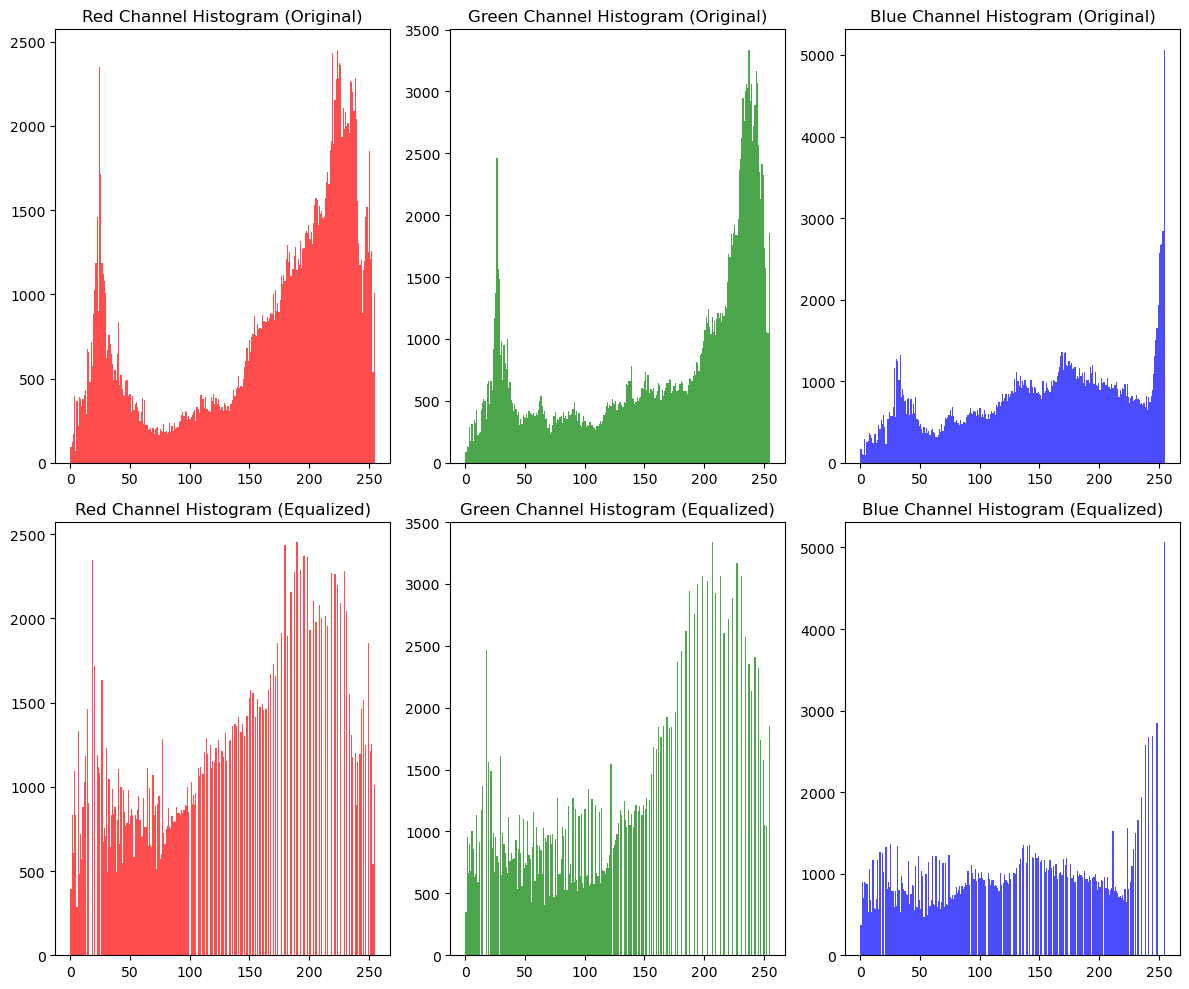

In [10]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load the image
image_path = "C:/Users/student/Documents/Computer Vision 2023510051/Shawn.webp"
image = cv2.imread(image_path)

# Convert the image from BGR to RGB (OpenCV loads images in BGR by default)
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Split the image into its RGB channels
r, g, b = cv2.split(rgb_image)

# Perform histogram equalization on each channel
r_equalized = cv2.equalizeHist(r)
g_equalized = cv2.equalizeHist(g)
b_equalized = cv2.equalizeHist(b)

# Merge the equalized channels back together
equalized_rgb_image = cv2.merge([r_equalized, g_equalized, b_equalized])

# Plot the original and equalized images along with their histograms for each color channel
fig, axes = plt.subplots(2, 3, figsize=(12, 10))

# Histogram for the Red channel (Original)
axes[0, 0].hist(r.ravel(), bins=256, color='red', alpha=0.7)
axes[0, 0].set_title('Red Channel Histogram (Original)')

# Histogram for the Green channel (Original)
axes[0, 1].hist(g.ravel(), bins=256, color='green', alpha=0.7)
axes[0, 1].set_title('Green Channel Histogram (Original)')

# Histogram for the Blue channel (Original)
axes[0, 2].hist(b.ravel(), bins=256, color='blue', alpha=0.7)
axes[0, 2].set_title('Blue Channel Histogram (Original)')

# Histogram for the Red channel (Equalized)
axes[1, 0].hist(r_equalized.ravel(), bins=256, color='red', alpha=0.7)
axes[1, 0].set_title('Red Channel Histogram (Equalized)')

# Histogram for the Green channel (Equalized)
axes[1, 1].hist(g_equalized.ravel(), bins=256, color='green', alpha=0.7)
axes[1, 1].set_title('Green Channel Histogram (Equalized)')

# Histogram for the Blue channel (Equalized)
axes[1, 2].hist(b_equalized.ravel(), bins=256, color='blue', alpha=0.7)
axes[1, 2].set_title('Blue Channel Histogram (Equalized)')

# Show the plot
plt.tight_layout()
plt.show()
